# Digital Twin for HAADF and EDS



### Quick Start Code Cell

In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [11]:
# ── Config ────────────────────────────────────────────────────────────────────
DB_HOST = "localhost"
DB_PORT = 9000
server_list = [("stage", "asyncroscopy.hardware.STAGE"),
                     ("scan", "asyncroscopy.hardware.SCAN"),
                     ("eds", "asyncroscopy.detectors.EDS")]
# ─────────────────────────────────────────────────────────────────────────────

PROJECT_DIR = os.path.dirname(os.getcwd())
os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"
env = {**os.environ, "TANGO_HOST": f"{DB_HOST}:{DB_PORT}"}
processes = {}

def popen(cmd):
    return subprocess.Popen(cmd, env=env, cwd=PROJECT_DIR, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

def wait_for_device(name, timeout=60, interval=1):
    print(f"  Waiting for {name}...", end="", flush=True)
    start = time.time()
    while time.time() - start < timeout:
        try:
            tango.DeviceProxy(name).ping()
            print(f" ✅ ready ({time.time()-start:.1f}s)"); return True
        except:
            print(".", end="", flush=True); time.sleep(interval)
    print(f" ❌ timed out after {timeout}s"); return False

def check_processes(*names):
    for name in names:
        p = processes[name]
        print(f"\n─── {name} (PID {p.pid}) ───\n  Running: {p.poll() is None}")
        for label, fd in [("STDOUT", p.stdout), ("STDERR", p.stderr)]:
            try: print(f"  {label}: {fd.read1(4096).decode() or '(empty)'}")
            except: print(f"  {label}: (no output yet)")

# Kill old processes (if any)
print("Clearing old processes...")
for cmd in [f"kill -9 $(lsof -t -i:{DB_PORT}) 2>/dev/null || true",
            *[f"pkill -f '{module.split('.')[-1]} {name}_instance' 2>/dev/null || true"
              for name, module in server_list],
            "pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true"]:
    subprocess.run(cmd, shell=True)
time.sleep(2)

# Start DB
print(f"Project dir: {PROJECT_DIR}\nStarting Tango Database...")
processes["database"] = popen(["uv", "run", "python", "-m", "tango.databaseds.database", "2"])
print("  Waiting for database...", end="", flush=True)
for _ in range(30):
    try: tango.Database(DB_HOST, DB_PORT); print(" ✅ ready"); break
    except: print(".", end="", flush=True); time.sleep(1)

# Register devices
print("Registering devices...")
r = subprocess.run(["uv", "run", "scripts/2_register_devices.py"], env=env, cwd=PROJECT_DIR, capture_output=True, text=True)
print(r.stdout.strip())
if r.returncode != 0:
    print("ERROR:", r.stderr); raise RuntimeError("Device registration failed — stopping here.")

# Start servers
print("Starting device servers...")
for name, module in server_list:
    processes[name] = popen(["uv", "run", "python", "-m", module, f"{name}_instance"])

if not all(wait_for_device(f"test/{d}/1") for d in ["stage", "scan", "eds"]):
    raise RuntimeError("Stage/Scan/EDS server failed.")

print("Starting Microscope...")
processes["microscope"] = popen(["uv", "run", "python", "-m", "asyncroscopy.ThermoMicroscope", "microscope_instance"])
if not wait_for_device("test/microscope/1"):
    print("\n⚠️  Debug info:"); check_processes("microscope")
    raise RuntimeError("Microscope server failed — see debug info above.")

print("\n✅ All servers ready!")

Clearing old processes...
Project dir: /Users/austin/Documents/GitHub/asyncroscopy
Starting Tango Database...
  Waiting for database.... ✅ ready
Registering devices...
Connected: stingray-zm68g.device.utk.edu:9000

  registered: test/scan/1
  registered: test/eds/1
  registered: test/stage/1
  registered: test/microscope/1
  property:   scan_device_address = test/scan/1
  property:   eds_device_address = test/eds/1
  property:   stage_device_address = test/stage/1

Done!
Starting device servers...
  Waiting for test/stage/1.... ✅ ready (1.0s)
  Waiting for test/scan/1... ✅ ready (0.0s)
  Waiting for test/eds/1... ✅ ready (0.0s)
Starting Microscope...
  Waiting for test/microscope/1.... ✅ ready (1.0s)

✅ All servers ready!


## 1. Connect to devices

In [12]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:9000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"


# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/microscope/1
test/scan/1
test/stage/1


In [13]:
scan = tango.DeviceProxy("test/scan/1")
mic = tango.DeviceProxy("test/microscope/1")

scan.set_timeout_millis(120_000)
mic.set_timeout_millis(120_000)

In [14]:
## helper funcs.
def get_image(dwell=10e-6, imsize=512):
    scan.dwell_time = dwell
    scan.imsize  = imsize

    json_meta, raw_bytes = mic.get_scanned_image()
    metadata  = dict(json.loads(json_meta))
    image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

    return image, metadata

### Begin

Stage position: [-1.0346733e-04 -9.3968818e-05 -2.1535667e-04  2.1314915e-02
  5.4559924e-02]


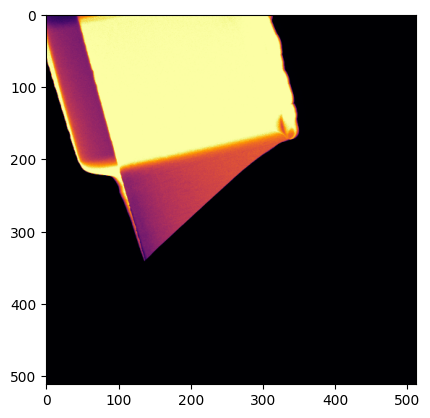

In [15]:
# Get image
starting_image, metadata = get_image()
plt.figure()
plt.imshow(starting_image, cmap='inferno')

# Get Stage
starting_position = mic.get_stage()
print('Stage position:', starting_position)

### Now tilt and image

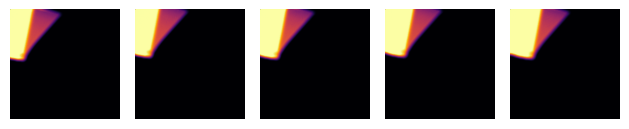

In [16]:
# Move the stage in alpha
step_size = 2 # degree

images = []
for i in range(5):
    new_position = starting_position + np.array([0, 0, 0, step_size*i, 0])
    mic.move_stage(new_position)
    im, met = get_image()
    images.append(im)

fig, ax = plt.subplots(1,5,sharex=True,sharey=True)
for i in range(5):
    ax[i].imshow(images[i].T, cmap='inferno')
    ax[i].axis('off')
fig.tight_layout()


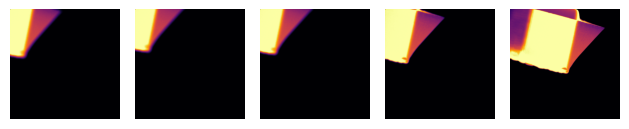

In [18]:
# Move the stage in beta
step_size = 0.5 # degree

images = []
for i in range(5):
    new_position = starting_position + np.array([0, 0, 0, 0, step_size*i])
    mic.move_stage(new_position)
    im, met = get_image()
    images.append(im)

fig, ax = plt.subplots(1,5,sharex=True,sharey=True)
for i in range(5):
    ax[i].imshow(images[i].T, cmap='inferno')
    ax[i].axis('off')
fig.tight_layout()

### Okay, but with drift correction

In [28]:
fov = mic.get_fov()
pixel_size = fov / met['shape'][0]

Estimated drift in pixels (dy, dx):
step 0: (0, 0)
step 1: (np.int64(0), np.int64(2))
step 2: (np.int64(0), np.int64(0))
step 3: (np.int64(0), np.int64(1))
step 4: (np.int64(0), np.int64(1))

Applied stage corrections (dx_stage, dy_stage):
step 0: (0.0, 0.0)
step 1: (np.float64(-6.640625e-08), np.float64(0.0))
step 2: (np.float64(0.0), np.float64(0.0))
step 3: (np.float64(-3.3203125e-08), np.float64(0.0))
step 4: (np.float64(-3.3203125e-08), np.float64(0.0))


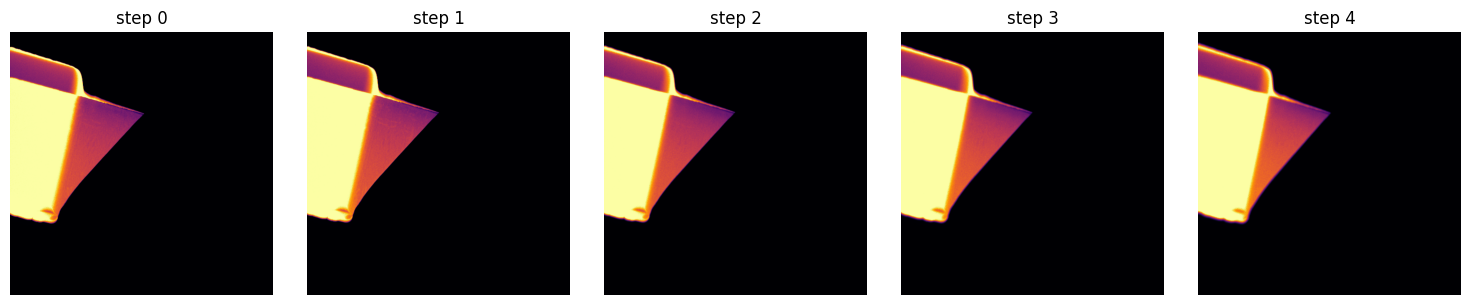

In [31]:
from scipy.signal import fftconvolve

def phase_corr_shift(img_ref, img_new, upsample=False):
    """
    Estimate translational shift between two images.
    Returns (dy, dx) in pixels such that shifting img_new by (-dy, -dx)
    aligns it to img_ref.
    """
    a = img_ref.astype(np.float32)
    b = img_new.astype(np.float32)

    # remove mean and normalize a bit for robustness
    a = a - np.mean(a)
    b = b - np.mean(b)

    # optional: normalize by std to reduce contrast sensitivity
    a_std = np.std(a)
    b_std = np.std(b)
    if a_std > 0:
        a = a / a_std
    if b_std > 0:
        b = b / b_std

    # FFT cross-correlation
    corr = fftconvolve(a, b[::-1, ::-1], mode='same')
    maxpos = np.unravel_index(np.argmax(corr), corr.shape)

    cy, cx = np.array(corr.shape) // 2
    dy = maxpos[0] - cy
    dx = maxpos[1] - cx

    return dy, dx


def pixels_to_stage_shift(dx_pix, dy_pix, pixel_size_x, pixel_size_y):
    """
    Convert image pixel shift to stage correction in stage units.
    You must check sign convention on your microscope.

    Returns (stage_dx, stage_dy)
    """
    stage_dx = -dx_pix * pixel_size_x
    stage_dy = -dy_pix * pixel_size_y
    return stage_dx, stage_dy


# --- user parameters ---
step_size = 0.5  # degrees
n_steps = 5


images = []
positions = []
drift_pixels = []
stage_corrections = []

# initial reference
current_position = starting_position.copy()
mic.move_stage(current_position)
ref_im, ref_met = get_image()

images.append(ref_im)
positions.append(current_position.copy())
drift_pixels.append((0, 0))
stage_corrections.append((0.0, 0.0))

for i in range(1, n_steps):
    # 1) nominal next tilt position
    new_position = current_position.copy()
    new_position[4] = starting_position[4] + step_size * i
    mic.move_stage(new_position)

    # 2) acquire after tilt
    im_raw, met = get_image()

    # 3) estimate drift relative to previous corrected image
    dy_pix, dx_pix = phase_corr_shift(ref_im, im_raw)
    drift_pixels.append((dy_pix, dx_pix))

    # 4) convert drift to stage correction
    stage_dx, stage_dy = pixels_to_stage_shift(
        dx_pix, dy_pix,
        pixel_size_x=pixel_size,
        pixel_size_y=pixel_size
    )
    stage_corrections.append((stage_dx, stage_dy))

    # 5) apply correction
    corrected_position = new_position.copy()
    corrected_position[0] += stage_dx
    corrected_position[1] += stage_dy
    mic.move_stage(corrected_position)

    # 6) reacquire corrected image
    im_corr, met_corr = get_image()

    images.append(im_corr)
    positions.append(corrected_position.copy())

    # update reference for next step
    ref_im = im_corr
    current_position = corrected_position.copy()

# plot
fig, ax = plt.subplots(1, n_steps, figsize=(3 * n_steps, 3), sharex=True, sharey=True)
for i in range(n_steps):
    ax[i].imshow(images[i].T, cmap='inferno')
    ax[i].set_title(f"step {i}")
    ax[i].axis('off')
fig.tight_layout()

print("Estimated drift in pixels (dy, dx):")
for i, d in enumerate(drift_pixels):
    print(f"step {i}: {d}")

print("\nApplied stage corrections (dx_stage, dy_stage):")
for i, c in enumerate(stage_corrections):
    print(f"step {i}: {c}")

### GPT Codex

In [ ]:
from scipy.signal import fftconvolve
from scipy import ndimage


def phase_corr_shift(img_ref, img_new):
    """
    Estimate the translational shift between two images.

    Returns (dy, dx) in pixels such that shifting ``img_new`` by ``(-dy, -dx)``
    best aligns it to ``img_ref``.
    """
    a = img_ref.astype(np.float32)
    b = img_new.astype(np.float32)

    a = a - np.mean(a)
    b = b - np.mean(b)

    a_std = np.std(a)
    b_std = np.std(b)
    if a_std > 0:
        a = a / a_std
    if b_std > 0:
        b = b / b_std

    corr = fftconvolve(a, b[::-1, ::-1], mode='same')
    maxpos = np.unravel_index(np.argmax(corr), corr.shape)

    cy, cx = np.array(corr.shape) // 2
    dy = float(maxpos[0] - cy)
    dx = float(maxpos[1] - cx)
    return dy, dx


def pixels_to_stage_shift(dx_pix, dy_pix, pixel_size_x, pixel_size_y):
    """
    Convert image shift in pixels into stage correction in metres.

    The sign convention here assumes that a positive image shift should be
    corrected by moving the stage in the opposite direction.
    """
    stage_dx = -dx_pix * pixel_size_x
    stage_dy = -dy_pix * pixel_size_y
    return stage_dx, stage_dy


def fit_tilt_shift_model(angles_deg, shifts_dx_pix, shifts_dy_pix, reference_angle_deg=0.0):
    """
    Fit a physically-motivated single-axis tilt model:

        shift(theta) = a * sin(dtheta) + b * (1 - cos(dtheta))

    This is the expected image motion for an object rotating around a fixed pivot
    with the reference image captured at dtheta = 0.
    """
    angles_deg = np.asarray(angles_deg, dtype=np.float64)
    shifts_dx_pix = np.asarray(shifts_dx_pix, dtype=np.float64)
    shifts_dy_pix = np.asarray(shifts_dy_pix, dtype=np.float64)

    dtheta = np.radians(angles_deg - reference_angle_deg)
    design = np.column_stack([
        np.sin(dtheta),
        1.0 - np.cos(dtheta),
    ])

    coeff_dx, *_ = np.linalg.lstsq(design, shifts_dx_pix, rcond=None)
    coeff_dy, *_ = np.linalg.lstsq(design, shifts_dy_pix, rcond=None)

    pred_dx = design @ coeff_dx
    pred_dy = design @ coeff_dy

    return {
        'reference_angle_deg': float(reference_angle_deg),
        'coeff_dx': coeff_dx,
        'coeff_dy': coeff_dy,
        'fit_rms_dx_pix': float(np.sqrt(np.mean((pred_dx - shifts_dx_pix) ** 2))),
        'fit_rms_dy_pix': float(np.sqrt(np.mean((pred_dy - shifts_dy_pix) ** 2))),
    }


def predict_tilt_shift(model, angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=np.float64)
    dtheta = np.radians(angle_deg - model['reference_angle_deg'])
    design = np.column_stack([
        np.sin(np.atleast_1d(dtheta)),
        1.0 - np.cos(np.atleast_1d(dtheta)),
    ])

    pred_dx = design @ model['coeff_dx']
    pred_dy = design @ model['coeff_dy']

    if np.ndim(angle_deg) == 0:
        return float(pred_dy[0]), float(pred_dx[0])
    return pred_dy, pred_dx


def software_align_image(img, dy_pix, dx_pix):
    return ndimage.shift(
        img.astype(np.float32),
        shift=(-dy_pix, -dx_pix),
        order=1,
        mode='nearest',
        prefilter=False,
    )


def reconstruct_volume_from_tilt_series(aligned_images, angles_deg):
    """
    Reconstruct a simple single-axis volume using row-wise inverse Radon.

    Assumes the tilt axis is parallel to the image y-axis. If your tilt axis is
    rotated in the camera frame, rotate the images first or add a tilt-axis
    registration step before reconstruction.
    """
    try:
        from skimage.transform import iradon
    except ImportError:
        print('scikit-image is not installed; skipping 3D reconstruction.')
        return None

    stack = np.stack(aligned_images, axis=0).astype(np.float32)
    _, n_rows, n_cols = stack.shape

    volume = np.zeros((n_rows, n_cols, n_cols), dtype=np.float32)
    for row in range(n_rows):
        sinogram = stack[:, row, :].T
        volume[row] = iradon(sinogram, theta=np.asarray(angles_deg), circle=False, filter_name='ramp')

    return volume


def collect_tilt_calibration(starting_position, ref_im, calibration_angles_deg, tilt_axis_index, settle_time_s=0.0):
    measurements = []

    for angle_deg in calibration_angles_deg:
        stage_position = starting_position.copy()
        stage_position[tilt_axis_index] = starting_position[tilt_axis_index] + angle_deg
        mic_proxy.move_stage(stage_position)

        if settle_time_s > 0:
            time.sleep(settle_time_s)

        image, metadata = get_image()
        shift_dy_pix, shift_dx_pix = phase_corr_shift(ref_im, image)

        measurements.append({
            'angle_deg': float(angle_deg),
            'position': np.array(stage_position, dtype=np.float64),
            'image': image,
            'metadata': metadata,
            'shift_dy_pix': float(shift_dy_pix),
            'shift_dx_pix': float(shift_dx_pix),
        })

    return measurements


# --- user parameters ---
# Stage convention in this repo is [x, y, z, alpha, beta]. Use 3 for alpha tilt.
tilt_axis_index = 3
calibration_angles_deg = np.arange(-8, 10, 2)
prediction_angles_deg = np.arange(-12, 13, 3)
settle_time_s = 0.0
apply_residual_correction = True
return_to_start = True
perform_3d_reconstruction = True


# --- acquire a reference at the starting pose ---
starting_position = np.array(mic_proxy.get_stage(), dtype=np.float64)
mic_proxy.move_stage(starting_position)
ref_im, ref_met = get_image()


# --- 1) Measure how image drift changes with tilt angle ---
calibration_measurements = collect_tilt_calibration(
    starting_position=starting_position,
    ref_im=ref_im,
    calibration_angles_deg=calibration_angles_deg,
    tilt_axis_index=tilt_axis_index,
    settle_time_s=settle_time_s,
)

calibration_dx_pix = np.array([m['shift_dx_pix'] for m in calibration_measurements])
calibration_dy_pix = np.array([m['shift_dy_pix'] for m in calibration_measurements])
model = fit_tilt_shift_model(
    angles_deg=calibration_angles_deg,
    shifts_dx_pix=calibration_dx_pix,
    shifts_dy_pix=calibration_dy_pix,
    reference_angle_deg=0.0,
)

fit_dy_pix, fit_dx_pix = predict_tilt_shift(model, calibration_angles_deg)


# --- 2) Use the fitted model to pre-compensate x/y as the tilt is executed ---
prediction_results = []
aligned_images = []

for angle_deg in prediction_angles_deg:
    nominal_position = starting_position.copy()
    nominal_position[tilt_axis_index] = starting_position[tilt_axis_index] + angle_deg

    pred_dy_pix, pred_dx_pix = predict_tilt_shift(model, angle_deg)
    pred_stage_dx, pred_stage_dy = pixels_to_stage_shift(
        pred_dx_pix,
        pred_dy_pix,
        pixel_size_x=pixel_size,
        pixel_size_y=pixel_size,
    )

    predicted_position = nominal_position.copy()
    predicted_position[0] += pred_stage_dx
    predicted_position[1] += pred_stage_dy
    mic_proxy.move_stage(predicted_position)

    if settle_time_s > 0:
        time.sleep(settle_time_s)

    im_pred, met_pred = get_image()
    residual_dy_pix, residual_dx_pix = phase_corr_shift(ref_im, im_pred)

    corrected_position = predicted_position.copy()
    corrected_im = im_pred
    residual_stage_dx = 0.0
    residual_stage_dy = 0.0

    if apply_residual_correction:
        residual_stage_dx, residual_stage_dy = pixels_to_stage_shift(
            residual_dx_pix,
            residual_dy_pix,
            pixel_size_x=pixel_size,
            pixel_size_y=pixel_size,
        )
        corrected_position[0] += residual_stage_dx
        corrected_position[1] += residual_stage_dy
        mic_proxy.move_stage(corrected_position)

        if settle_time_s > 0:
            time.sleep(settle_time_s)

        corrected_im, met_corr = get_image()
    else:
        met_corr = met_pred

    final_dy_pix, final_dx_pix = phase_corr_shift(ref_im, corrected_im)
    aligned_images.append(software_align_image(corrected_im, final_dy_pix, final_dx_pix))

    prediction_results.append({
        'angle_deg': float(angle_deg),
        'predicted_position': predicted_position.copy(),
        'corrected_position': corrected_position.copy(),
        'predicted_shift_pix': (float(pred_dy_pix), float(pred_dx_pix)),
        'residual_before_correction_pix': (float(residual_dy_pix), float(residual_dx_pix)),
        'residual_after_correction_pix': (float(final_dy_pix), float(final_dx_pix)),
        'predicted_stage_correction_m': (float(pred_stage_dx), float(pred_stage_dy)),
        'residual_stage_correction_m': (float(residual_stage_dx), float(residual_stage_dy)),
        'image': corrected_im,
        'metadata': met_corr,
    })

if return_to_start:
    mic_proxy.move_stage(starting_position)


# --- 3) Reconstruct a simple 3D volume from the aligned tilt series ---
reconstructed_volume = None
if perform_3d_reconstruction:
    reconstructed_volume = reconstruct_volume_from_tilt_series(aligned_images, prediction_angles_deg)


# --- visualization ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(calibration_angles_deg, calibration_dx_pix, 'o', label='measured dx')
axes[0, 0].plot(calibration_angles_deg, fit_dx_pix, '-', label='fit dx')
axes[0, 0].plot(calibration_angles_deg, calibration_dy_pix, 's', label='measured dy')
axes[0, 0].plot(calibration_angles_deg, fit_dy_pix, '--', label='fit dy')
axes[0, 0].set_title('Tilt-to-drift calibration')
axes[0, 0].set_xlabel('Tilt offset (deg)')
axes[0, 0].set_ylabel('Shift (pixels)')
axes[0, 0].legend()

residual_before = np.array([r['residual_before_correction_pix'] for r in prediction_results])
residual_after = np.array([r['residual_after_correction_pix'] for r in prediction_results])
axes[0, 1].plot(prediction_angles_deg, residual_before[:, 1], 'o-', label='dx before residual fix')
axes[0, 1].plot(prediction_angles_deg, residual_before[:, 0], 's-', label='dy before residual fix')
axes[0, 1].plot(prediction_angles_deg, residual_after[:, 1], 'o--', label='dx after residual fix')
axes[0, 1].plot(prediction_angles_deg, residual_after[:, 0], 's--', label='dy after residual fix')
axes[0, 1].set_title('Prediction residuals')
axes[0, 1].set_xlabel('Tilt offset (deg)')
axes[0, 1].set_ylabel('Residual shift (pixels)')
axes[0, 1].legend()

montage = np.concatenate(aligned_images, axis=1)
axes[1, 0].imshow(montage.T, cmap='inferno')
axes[1, 0].set_title('Aligned tilt series')
axes[1, 0].axis('off')

if reconstructed_volume is not None:
    mid_row = reconstructed_volume.shape[0] // 2
    mid_col = reconstructed_volume.shape[1] // 2
    xz_slice = reconstructed_volume[mid_row]
    yz_slice = reconstructed_volume[:, mid_col, :]
    preview = np.concatenate([xz_slice, yz_slice], axis=1)
    axes[1, 1].imshow(preview.T, cmap='viridis')
    axes[1, 1].set_title('3D reconstruction preview (XZ | YZ)')
    axes[1, 1].axis('off')
else:
    axes[1, 1].text(0.5, 0.5, '3D reconstruction skipped', ha='center', va='center')
    axes[1, 1].set_axis_off()

fig.tight_layout()

print('Calibration fit RMS (pixels):')
print(f"  dx: {model['fit_rms_dx_pix']:.3f}")
print(f"  dy: {model['fit_rms_dy_pix']:.3f}")

print('\nPredicted stage corrections:')
for result in prediction_results:
    print(
        f"  angle {result['angle_deg']:>5.1f} deg | "
        f"pred shift (dy, dx)=({result['predicted_shift_pix'][0]:>6.2f}, {result['predicted_shift_pix'][1]:>6.2f}) px | "
        f"pred stage (dx, dy)=({result['predicted_stage_correction_m'][0]:+.3e}, {result['predicted_stage_correction_m'][1]:+.3e}) m"
    )

print('\nResidual drift after prediction/correction:')
for result in prediction_results:
    dy_pix, dx_pix = result['residual_after_correction_pix']
    print(f"  angle {result['angle_deg']:>5.1f} deg | residual (dy, dx)=({dy_pix:>6.2f}, {dx_pix:>6.2f}) px")



### Z-correction?
I'm assumung this is going to be a problem...